In [94]:
import pandas as pd
import numpy as np
import joblib
import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostRegressor

from sklearn.model_selection import train_test_split, RandomizedSearchCV, KFold
from sklearn.metrics import mean_absolute_error
from scipy.stats import spearmanr
from scipy.optimize import minimize

import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [95]:
# Load v3 features (74 engineered + 8 BG/NBD = 82 features)
features = pd.read_csv("../data/customer_features_v3.csv")
train    = pd.read_csv("../data/customer_clv_train.csv")

df = train.merge(features, on="cust_id", how="left")
print(f"Shape: {df.shape}  |  Revenue > 0: {(df['revenue_2018_2019'] > 0).mean():.1%}")
print(f"Feature columns in v3: {features.shape[1] - 1}")

Shape: (116591, 83)  |  Revenue > 0: 36.6%
Feature columns in v3: 81


In [96]:
# All ML feature columns = every numeric col except IDs and target
feature_cols_ml = df.select_dtypes(include=[np.number]).columns.tolist()
feature_cols_ml = [c for c in feature_cols_ml
                   if c not in ("cust_id", "revenue_2018_2019")]

# Identify BG/NBD columns for reporting
bgnbd_cols = [c for c in feature_cols_ml
              if c in ("p_alive", "exp_purchases_24m", "exp_avg_revenue",
                       "bgnbd_clv", "bgnbd_frequency", "bgnbd_recency",
                       "bgnbd_T", "bgnbd_monetary_value")]

print(f"Total ML features: {len(feature_cols_ml)}")
print(f"BG/NBD features included: {bgnbd_cols}")

# Fill any NaNs (one-time buyers may have NaN from Gamma-Gamma)
nan_counts = df[feature_cols_ml].isnull().sum()
if nan_counts.any():
    print(f"\nNaN columns: {nan_counts[nan_counts > 0].to_dict()}")
    df[feature_cols_ml] = df[feature_cols_ml].fillna(0)
    print("Filled with 0.")

Total ML features: 81
BG/NBD features included: ['bgnbd_frequency', 'bgnbd_monetary_value', 'p_alive', 'exp_purchases_24m', 'exp_avg_revenue', 'bgnbd_clv']


In [97]:
# 80/20 holdout split — val set used only for final reporting
df_train, df_val = train_test_split(df, test_size=0.2, random_state=42)
df_train = df_train.reset_index(drop=True)
df_val   = df_val.reset_index(drop=True)

X_train      = df_train[feature_cols_ml].values
y_train_log  = np.log1p(df_train["revenue_2018_2019"].values)
y_train_raw  = df_train["revenue_2018_2019"].values

X_val        = df_val[feature_cols_ml].values
y_val_raw    = df_val["revenue_2018_2019"].values

print(f"Train: {len(X_train)}  |  Val: {len(X_val)}")
print(f"Train zero-revenue fraction: {(y_train_raw == 0).mean():.1%}")
print(f"Val   zero-revenue fraction: {(y_val_raw  == 0).mean():.1%}")

# 5-fold CV used for OOF evaluation of ensemble weights
kf = KFold(n_splits=5, shuffle=True, random_state=42)

Train: 93272  |  Val: 23319
Train zero-revenue fraction: 63.4%
Val   zero-revenue fraction: 63.3%


# Hyperparameter Optimisation with Optuna

Optuna's **TPE (Tree-structured Parzen Estimator)** sampler learns which hyperparameter regions produce low loss after each trial and focuses exploration there — far more efficient than RandomizedSearchCV's blind random sampling.

- **60 trials × 3-fold CV** for LightGBM and XGBoost
- **40 trials × 3-fold CV** for CatBoost (slower per trial)
- Wider search ranges than before (especially `learning_rate`, `num_leaves`, `reg_*`)
- Same 5-fold OOF evaluation afterwards with the winning params


In [98]:
try:
    import optuna
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "optuna", "-q"])
    import optuna

from sklearn.model_selection import cross_val_score
optuna.logging.set_verbosity(optuna.logging.WARNING)

# 3-fold CV inside Optuna (fast proxy); full 5-fold OOF done afterwards
cv_opt = KFold(n_splits=3, shuffle=True, random_state=0)

def objective_lgb(trial):
    params = {
        "n_estimators":      trial.suggest_int("n_estimators", 300, 3000),
        "learning_rate":     trial.suggest_float("learning_rate", 0.005, 0.15, log=True),
        "num_leaves":        trial.suggest_int("num_leaves", 20, 300),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 100),
        "subsample":         trial.suggest_float("subsample", 0.4, 1.0),
        "colsample_bytree":  trial.suggest_float("colsample_bytree", 0.4, 1.0),
        "reg_alpha":         trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        "reg_lambda":        trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
    }
    model = lgb.LGBMRegressor(objective="regression_l1", random_state=42,
                               n_jobs=-1, verbose=-1, **params)
    scores = cross_val_score(model, X_train, y_train_log, cv=cv_opt,
                             scoring="neg_mean_absolute_error", n_jobs=1)
    return -scores.mean()

study_lgb = optuna.create_study(direction="minimize",
                                sampler=optuna.samplers.TPESampler(seed=42))
study_lgb.optimize(objective_lgb, n_trials=60, show_progress_bar=True)
best_lgb_params = study_lgb.best_params
print(f"LightGBM best params: {best_lgb_params}")
print(f"LightGBM Optuna best CV MAE (log-space): {study_lgb.best_value:.4f}")

# 5-fold OOF with best params
oof_lgb = np.zeros(len(X_train))
for tr_idx, val_idx in kf.split(X_train):
    m = lgb.LGBMRegressor(objective="regression_l1", random_state=42,
                           n_jobs=-1, verbose=-1, **best_lgb_params)
    m.fit(X_train[tr_idx], y_train_log[tr_idx])
    oof_lgb[val_idx] = m.predict(X_train[val_idx])

oof_lgb_raw = np.expm1(oof_lgb).clip(0)
oof_lgb_mae, (oof_lgb_sp, _) = (mean_absolute_error(y_train_raw, oof_lgb_raw),
                                  spearmanr(y_train_raw, oof_lgb_raw))
print(f"LightGBM OOF → MAE: {oof_lgb_mae:.2f}  Spearman: {oof_lgb_sp:.4f}")


Best trial: 7. Best value: 1.4538: 100%|██████████| 60/60 [1:35:21<00:00, 95.35s/it] 


LightGBM best params: {'n_estimators': 539, 'learning_rate': 0.009737791153147714, 'num_leaves': 32, 'min_child_samples': 36, 'subsample': 0.6332063738136893, 'colsample_bytree': 0.5628094190643376, 'reg_alpha': 0.287499823474079, 'reg_lambda': 1.6247252885719427e-05}
LightGBM Optuna best CV MAE (log-space): 1.4538
LightGBM OOF → MAE: 62.58  Spearman: 0.3933


# XGBoost — Optuna

In [99]:
def objective_xgb(trial):
    params = {
        "n_estimators":     trial.suggest_int("n_estimators", 300, 3000),
        "learning_rate":    trial.suggest_float("learning_rate", 0.005, 0.15, log=True),
        "max_depth":        trial.suggest_int("max_depth", 3, 8),
        "subsample":        trial.suggest_float("subsample", 0.4, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.4, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 20),
        "reg_alpha":        trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        "reg_lambda":       trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
        "gamma":            trial.suggest_float("gamma", 1e-8, 1.0, log=True),
    }
    model = xgb.XGBRegressor(objective="reg:absoluteerror", random_state=42,
                              n_jobs=-1, verbosity=0, **params)
    scores = cross_val_score(model, X_train, y_train_log, cv=cv_opt,
                             scoring="neg_mean_absolute_error", n_jobs=1)
    return -scores.mean()

study_xgb = optuna.create_study(direction="minimize",
                                sampler=optuna.samplers.TPESampler(seed=42))
study_xgb.optimize(objective_xgb, n_trials=60, show_progress_bar=True)
best_xgb_params = study_xgb.best_params
print(f"XGBoost best params: {best_xgb_params}")
print(f"XGBoost Optuna best CV MAE (log-space): {study_xgb.best_value:.4f}")

# 5-fold OOF
oof_xgb = np.zeros(len(X_train))
for tr_idx, val_idx in kf.split(X_train):
    m = xgb.XGBRegressor(objective="reg:absoluteerror", random_state=42,
                          n_jobs=-1, verbosity=0, **best_xgb_params)
    m.fit(X_train[tr_idx], y_train_log[tr_idx])
    oof_xgb[val_idx] = m.predict(X_train[val_idx])

oof_xgb_raw = np.expm1(oof_xgb).clip(0)
oof_xgb_mae, (oof_xgb_sp, _) = (mean_absolute_error(y_train_raw, oof_xgb_raw),
                                  spearmanr(y_train_raw, oof_xgb_raw))
print(f"XGBoost OOF → MAE: {oof_xgb_mae:.2f}  Spearman: {oof_xgb_sp:.4f}")


Best trial: 58. Best value: 1.45854: 100%|██████████| 60/60 [1:30:24<00:00, 90.41s/it] 


XGBoost best params: {'n_estimators': 2241, 'learning_rate': 0.006800362193106756, 'max_depth': 4, 'subsample': 0.7928783693843529, 'colsample_bytree': 0.6714482680395759, 'min_child_weight': 17, 'reg_alpha': 6.538396962349914, 'reg_lambda': 1.1278864494593568, 'gamma': 6.864870685320349e-08}
XGBoost Optuna best CV MAE (log-space): 1.4585
XGBoost OOF → MAE: 62.73  Spearman: 0.3748


# CatBoost — Optuna

In [100]:
def objective_cat(trial):
    params = {
        "iterations":        trial.suggest_int("iterations", 300, 3000),
        "learning_rate":     trial.suggest_float("learning_rate", 0.005, 0.15, log=True),
        "depth":             trial.suggest_int("depth", 4, 10),
        "subsample":         trial.suggest_float("subsample", 0.4, 1.0),
        "colsample_bylevel": trial.suggest_float("colsample_bylevel", 0.4, 1.0),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 100),
        "l2_leaf_reg":       trial.suggest_float("l2_leaf_reg", 1e-8, 20.0, log=True),
    }
    model = CatBoostRegressor(loss_function="MAE", random_state=42,
                              verbose=False, **params)
    scores = cross_val_score(model, X_train, y_train_log, cv=cv_opt,
                             scoring="neg_mean_absolute_error", n_jobs=1)
    return -scores.mean()

study_cat = optuna.create_study(direction="minimize",
                                sampler=optuna.samplers.TPESampler(seed=42))
study_cat.optimize(objective_cat, n_trials=40, show_progress_bar=True)
best_cat_params = study_cat.best_params
print(f"CatBoost best params: {best_cat_params}")
print(f"CatBoost Optuna best CV MAE (log-space): {study_cat.best_value:.4f}")

# 5-fold OOF
oof_cat = np.zeros(len(X_train))
for tr_idx, val_idx in kf.split(X_train):
    m = CatBoostRegressor(loss_function="MAE", random_state=42,
                          verbose=False, **best_cat_params)
    m.fit(X_train[tr_idx], y_train_log[tr_idx])
    oof_cat[val_idx] = m.predict(X_train[val_idx])

oof_cat_raw = np.expm1(oof_cat).clip(0)
oof_cat_mae, (oof_cat_sp, _) = (mean_absolute_error(y_train_raw, oof_cat_raw),
                                  spearmanr(y_train_raw, oof_cat_raw))
print(f"CatBoost OOF → MAE: {oof_cat_mae:.2f}  Spearman: {oof_cat_sp:.4f}")


Best trial: 36. Best value: 1.45502: 100%|██████████| 40/40 [52:37<00:00, 78.95s/it] 


CatBoost best params: {'iterations': 2271, 'learning_rate': 0.006488375538096504, 'depth': 7, 'subsample': 0.8921584874563343, 'colsample_bylevel': 0.7312991311950221, 'min_child_samples': 65, 'l2_leaf_reg': 1.2386122935443498e-08}
CatBoost Optuna best CV MAE (log-space): 1.4550
CatBoost OOF → MAE: 62.50  Spearman: 0.3638


# Ensemble Weights — Nelder-Mead Optimization

Find weights (w_lgb, w_xgb, w_cat) that minimise OOF MAE.  
Weights are constrained to sum to 1 and stay positive via softmax parameterisation.

In [101]:
# Stack OOF predictions (raw revenue space, clipped to 0)
oof_stack = np.column_stack([oof_lgb_raw, oof_xgb_raw, oof_cat_raw])

def oof_mae_w(logits):
    w = np.exp(logits); w /= w.sum()
    return mean_absolute_error(y_train_raw, oof_stack @ w)

res_w = minimize(oof_mae_w, x0=[0.0, 0.0, 0.0], method="Nelder-Mead",
                 options={"maxiter": 10000, "xatol": 1e-6, "fatol": 1e-6})

w_opt = np.exp(res_w.x); w_opt /= w_opt.sum()
w_lgb, w_xgb, w_cat = w_opt
print(f"Optimal weights:  LGB={w_lgb:.3f}  XGB={w_xgb:.3f}  CAT={w_cat:.3f}")

oof_ml_blend = oof_stack @ w_opt
oof_ml_mae,  (oof_ml_sp,  _) = mean_absolute_error(y_train_raw, oof_ml_blend),  spearmanr(y_train_raw, oof_ml_blend)
oof_eq       = oof_stack.mean(axis=1)
oof_eq_mae,  (oof_eq_sp,  _) = mean_absolute_error(y_train_raw, oof_eq),        spearmanr(y_train_raw, oof_eq)
print(f"Weighted ensemble OOF → MAE: {oof_ml_mae:.2f}  Spearman: {oof_ml_sp:.4f}")
print(f"Equal-weight      OOF → MAE: {oof_eq_mae:.2f}  Spearman: {oof_eq_sp:.4f}")

Optimal weights:  LGB=0.238  XGB=0.214  CAT=0.548
Weighted ensemble OOF → MAE: 62.45  Spearman: 0.3729
Equal-weight      OOF → MAE: 62.47  Spearman: 0.3730


In [102]:
# BG/NBD standalone — already fit in notebook 03, evaluate directly
bgnbd_oof    = df_train["bgnbd_clv"].fillna(0).clip(0).values
bgnbd_mae,  (bgnbd_sp, _) = mean_absolute_error(y_train_raw, bgnbd_oof), spearmanr(y_train_raw, bgnbd_oof)
print(f"BG/NBD standalone (train)  → MAE: {bgnbd_mae:.2f}  Spearman: {bgnbd_sp:.4f}")

BG/NBD standalone (train)  → MAE: 88.62  Spearman: 0.2947


In [103]:
# Optimise blend weight α: prediction = α × bgnbd_clv + (1−α) × ML_ensemble
def blend_mae_fn(alpha_arr):
    a = float(np.clip(alpha_arr[0], 0, 1))
    return mean_absolute_error(y_train_raw, a * bgnbd_oof + (1 - a) * oof_ml_blend)

res_a = minimize(blend_mae_fn, x0=[0.1], method="Nelder-Mead",
                 options={"maxiter": 2000, "xatol": 1e-5})
alpha_opt = float(np.clip(res_a.x[0], 0, 1))

oof_blend     = alpha_opt * bgnbd_oof + (1 - alpha_opt) * oof_ml_blend
oof_blend_mae, (oof_blend_sp, _) = mean_absolute_error(y_train_raw, oof_blend), spearmanr(y_train_raw, oof_blend)

print(f"Optimal α (BG/NBD share): {alpha_opt:.4f}")
print()
print(f"{'Model':<32} {'OOF MAE':>9}  {'Spearman':>10}")
print("-" * 55)
for label, mae, sp in [
    ("BG/NBD standalone",          bgnbd_mae,    bgnbd_sp),
    ("LightGBM only",              oof_lgb_mae,  oof_lgb_sp),
    ("XGBoost only",               oof_xgb_mae,  oof_xgb_sp),
    ("CatBoost only",              oof_cat_mae,  oof_cat_sp),
    ("ML weighted ensemble",       oof_ml_mae,   oof_ml_sp),
    (f"ML + BG/NBD (α={alpha_opt:.2f})", oof_blend_mae, oof_blend_sp),
]:
    print(f"{label:<32} {mae:>9.2f}  {sp:>10.4f}")

best_oof_mae = min(oof_lgb_mae, oof_xgb_mae, oof_cat_mae, oof_ml_mae, oof_blend_mae)
USE_BLEND    = (oof_blend_mae <= min(oof_ml_mae, oof_lgb_mae, oof_xgb_mae, oof_cat_mae))
print(f"\nBest OOF MAE: {best_oof_mae:.2f}  →  USE_BLEND={USE_BLEND}")

Optimal α (BG/NBD share): 0.0000

Model                              OOF MAE    Spearman
-------------------------------------------------------
BG/NBD standalone                    88.62      0.2947
LightGBM only                        62.58      0.3933
XGBoost only                         62.73      0.3748
CatBoost only                        62.50      0.3638
ML weighted ensemble                 62.45      0.3729
ML + BG/NBD (α=0.00)                 62.45      0.3729

Best OOF MAE: 62.45  →  USE_BLEND=True


## P_alive Soft Scaling — Conditional Revenue × BG/NBD

Train on **returning customers only**, predict conditional revenue for every customer, then multiply by `p_alive`.  
No hard threshold: each customer's prediction is continuously scaled by their BG/NBD survival probability.

`final_pred = p_alive × E[revenue | customer is active]`

This directly reduces both arms:
- **Vertical arm** (predict > 0 for churners): low `p_alive` scales those predictions toward 0
- **Horizontal arm** (predict ≈ 0 for true returners): they have high `p_alive` so their conditional revenue comes through


In [104]:
# Reuse the best hyperparameters already found — no new search needed
p_alive_train = df_train["p_alive"].fillna(0).clip(0).values
oof_soft      = np.zeros(len(X_train))

for tr_idx, val_idx in kf.split(X_train):
    # Only returning customers in the training fold
    ret_mask = y_train_raw[tr_idx] > 0
    ret_idx  = tr_idx[ret_mask]

    # Fit 3 conditional revenue models on returners
    m_lgb = lgb.LGBMRegressor(objective="regression_l1", random_state=42,
                               n_jobs=-1, verbose=-1, **best_lgb_params)
    m_xgb = xgb.XGBRegressor(objective="reg:absoluteerror", random_state=42,
                              n_jobs=-1, verbosity=0, **best_xgb_params)
    m_cat = CatBoostRegressor(loss_function="MAE", random_state=42,
                              verbose=False, **best_cat_params)
    m_lgb.fit(X_train[ret_idx], y_train_log[ret_idx])
    m_xgb.fit(X_train[ret_idx], y_train_log[ret_idx])
    m_cat.fit(X_train[ret_idx], y_train_log[ret_idx])

    # Equal-weight conditional revenue ensemble → multiply by p_alive
    cond_log = (m_lgb.predict(X_train[val_idx]) +
                m_xgb.predict(X_train[val_idx]) +
                m_cat.predict(X_train[val_idx])) / 3
    cond_rev = np.expm1(cond_log).clip(0)
    oof_soft[val_idx] = p_alive_train[val_idx] * cond_rev

oof_soft_mae, (oof_soft_sp, _) = (mean_absolute_error(y_train_raw, oof_soft),
                                   spearmanr(y_train_raw, oof_soft))
print(f"P_alive soft scaling OOF → MAE: {oof_soft_mae:.2f}  Spearman: {oof_soft_sp:.4f}")

# Full OOF comparison
print(f"\n{'Model':<38} {'OOF MAE':>9}  {'Spearman':>10}")
print("-" * 61)
best_mae_all = min(bgnbd_mae, oof_ml_mae, oof_blend_mae, oof_soft_mae)
for label, mae, sp in [
    ("BG/NBD standalone",                    bgnbd_mae,    bgnbd_sp),
    ("ML weighted ensemble",                 oof_ml_mae,   oof_ml_sp),
    (f"ML + BG/NBD blend (α={alpha_opt:.2f})", oof_blend_mae, oof_blend_sp),
    ("P_alive × conditional revenue",        oof_soft_mae, oof_soft_sp),
]:
    marker = "  ◄ BEST" if mae == best_mae_all else ""
    print(f"{label:<38} {mae:>9.2f}  {sp:>10.4f}{marker}")

USE_SOFT_SCALING = (oof_soft_mae == best_mae_all)
print(f"\nUSE_SOFT_SCALING: {USE_SOFT_SCALING}")


P_alive soft scaling OOF → MAE: 109.40  Spearman: 0.3302

Model                                    OOF MAE    Spearman
-------------------------------------------------------------
BG/NBD standalone                          88.62      0.2947
ML weighted ensemble                       62.45      0.3729  ◄ BEST
ML + BG/NBD blend (α=0.00)                 62.45      0.3729  ◄ BEST
P_alive × conditional revenue             109.40      0.3302

USE_SOFT_SCALING: False


## Two-stage ML: Churn Classifier × Conditional Revenue

**Root cause of the MAE plateau**: 63.4 % of customers have €0 true revenue, yet all single-stage models predict a small positive number for most of them — there is no sharp zero boundary in log1p space.

**Strategy**:
1. **Stage 1 — Churn Classifier**: a dedicated LightGBM *binary classifier* uses all 80+ engineered features to predict **P(customer returns in 2018–2019)**.
2. **Stage 2 — Conditional Revenue**: the already Optuna-tuned LGB regressor predicts **E[revenue | customer is a returner]** (trained on returning customers only).
3. **Combination**: `prediction = P(return) × conditional_revenue`

**Why this differs from soft scaling** (which failed): soft scaling used BG/NBD `p_alive` as the multiplier — one probabilistic number from frequency/recency only. The classifier here is trained end-to-end on actual 2016–2017 → 2018–2019 churn labels and can exploit all 80+ engineered features.

An optional **prediction threshold** (optimised on OOF) then zeros out residual small predictions below the break-even level.

In [108]:
# ── Two-stage ML: Classifier × Conditional Revenue OOF ───────────────────────
from scipy.optimize import minimize_scalar

# Binary target: 1 = customer returned in 2018-2019, 0 = churned
y_train_binary = (y_train_raw > 0).astype(int)
print(f"Training set: {y_train_binary.sum()} returners ({y_train_binary.mean()*100:.1f}%), "
      f"{(1-y_train_binary).sum()} churners ({(1-y_train_binary).mean()*100:.1f}%)")

# Classifier hyperparams — reasonable defaults (reusing tree structure found by Optuna)
clf_lgb_params = {
    "n_estimators":      500,
    "learning_rate":     0.05,
    "num_leaves":        63,
    "min_child_samples": 20,
    "subsample":         0.8,
    "colsample_bytree":  0.8,
    "reg_alpha":         0.1,
    "reg_lambda":        1.0,
}

oof_twostage = np.zeros(len(X_train))
oof_p_return = np.zeros(len(X_train))

print("\nRunning 5-fold OOF for two-stage ML...")
for fold_i, (tr_idx, val_idx) in enumerate(kf.split(X_train)):
    # Stage 1: train binary churn classifier on all customers in train fold
    clf = lgb.LGBMClassifier(
        objective="binary", random_state=42, n_jobs=-1, verbose=-1,
        **clf_lgb_params,
    )
    clf.fit(X_train[tr_idx], y_train_binary[tr_idx])
    p_return = clf.predict_proba(X_train[val_idx])[:, 1]
    oof_p_return[val_idx] = p_return

    # Stage 2: train regressor on RETURNERS only in this fold
    ret_mask = y_train_binary[tr_idx] == 1
    ret_idx  = tr_idx[ret_mask]
    reg = lgb.LGBMRegressor(
        objective="regression_l1", random_state=42, n_jobs=-1, verbose=-1,
        **best_lgb_params,          # reuse Optuna-tuned params
    )
    reg.fit(X_train[ret_idx], y_train_log[ret_idx])
    cond_log = reg.predict(X_train[val_idx])
    cond_rev = np.expm1(cond_log).clip(0)

    oof_twostage[val_idx] = p_return * cond_rev
    fold_mae = mean_absolute_error(y_train_raw[val_idx], oof_twostage[val_idx])
    print(f"  Fold {fold_i+1}/5 — MAE: {fold_mae:.2f}")

oof_twostage_mae, (oof_twostage_sp, _) = (
    mean_absolute_error(y_train_raw, oof_twostage),
    spearmanr(y_train_raw, oof_twostage),
)
print(f"\nTwo-stage ML OOF → MAE: {oof_twostage_mae:.2f}  Spearman: {oof_twostage_sp:.4f}")

# ── Threshold post-processing (optimised on OOF) ─────────────────────────────
# Find the revenue threshold below which zeroing predictions reduces MAE
def threshold_mae_fn(t):
    return mean_absolute_error(y_train_raw, np.where(oof_twostage < t, 0.0, oof_twostage))

res_t = minimize_scalar(threshold_mae_fn, bounds=(0, 200), method="bounded")
best_threshold = float(res_t.x)
oof_thresholded = np.where(oof_twostage < best_threshold, 0.0, oof_twostage)
oof_thresh_mae, (oof_thresh_sp, _) = (
    mean_absolute_error(y_train_raw, oof_thresholded),
    spearmanr(y_train_raw, oof_thresholded),
)
print(f"Two-stage + threshold ({best_threshold:.1f}€) → MAE: {oof_thresh_mae:.2f}  Spearman: {oof_thresh_sp:.4f}")

# ── Full OOF comparison table (updated) ──────────────────────────────────────
print(f"\n{'Model':<44} {'OOF MAE':>9}  {'Spearman':>10}")
print("-" * 67)
best_mae_all = min(bgnbd_mae, oof_ml_mae, oof_blend_mae, oof_soft_mae,
                   oof_twostage_mae, oof_thresh_mae)
for label, mae, sp in [
    ("BG/NBD standalone",                         bgnbd_mae,        bgnbd_sp),
    ("ML weighted ensemble",                      oof_ml_mae,       oof_ml_sp),
    (f"ML + BG/NBD blend (α={alpha_opt:.2f})",    oof_blend_mae,    oof_blend_sp),
    ("P_alive × conditional revenue",             oof_soft_mae,     oof_soft_sp),
    ("Two-stage ML (clf × regressor)",            oof_twostage_mae, oof_twostage_sp),
    (f"Two-stage + threshold ({best_threshold:.0f}€)", oof_thresh_mae, oof_thresh_sp),
]:
    marker = "  ◄ BEST" if mae == best_mae_all else ""
    print(f"{label:<44} {mae:>9.2f}  {sp:>10.4f}{marker}")

USE_TWOSTAGE    = (min(oof_twostage_mae, oof_thresh_mae) < min(oof_ml_mae, oof_blend_mae, oof_soft_mae))
USE_THRESHOLD   = (USE_TWOSTAGE and (oof_thresh_mae < oof_twostage_mae))
USE_SOFT_SCALING = False   # shown to be worse in all experiments

print(f"\nUSE_TWOSTAGE={USE_TWOSTAGE}  USE_THRESHOLD={USE_THRESHOLD}  threshold={best_threshold:.1f}€")

Training set: 34106 returners (36.6%), 59166 churners (63.4%)

Running 5-fold OOF for two-stage ML...
  Fold 1/5 — MAE: 71.20
  Fold 2/5 — MAE: 72.12
  Fold 3/5 — MAE: 72.17
  Fold 4/5 — MAE: 71.46
  Fold 5/5 — MAE: 70.94

Two-stage ML OOF → MAE: 71.58  Spearman: 0.3985
Two-stage + threshold (83.9€) → MAE: 62.86  Spearman: 0.3858

Model                                          OOF MAE    Spearman
-------------------------------------------------------------------
BG/NBD standalone                                88.62      0.2947
ML weighted ensemble                             62.45      0.3729  ◄ BEST
ML + BG/NBD blend (α=0.00)                       62.45      0.3729  ◄ BEST
P_alive × conditional revenue                   109.40      0.3302
Two-stage ML (clf × regressor)                   71.58      0.3985
Two-stage + threshold (84€)                      62.86      0.3858

USE_TWOSTAGE=False  USE_THRESHOLD=False  threshold=83.9€


# Retrain on Full Training Data

Hyperparameters and ensemble weights are locked from OOF.  
Now retrain each model on the **full training set** for maximum signal before test prediction.

In [112]:
print("Retraining LightGBM on full training set...")
final_lgb = lgb.LGBMRegressor(objective="regression_l1", random_state=42, n_jobs=-1, verbose=-1,
                                **best_lgb_params)
final_lgb.fit(X_train, y_train_log)

print("Retraining XGBoost on full training set...")
final_xgb = xgb.XGBRegressor(objective="reg:absoluteerror", random_state=42, n_jobs=-1, verbosity=0,
                               **best_xgb_params)
final_xgb.fit(X_train, y_train_log)

print("Retraining CatBoost on full training set...")
final_cat = CatBoostRegressor(loss_function="MAE", random_state=42, verbose=False,
                               **best_cat_params)
final_cat.fit(X_train, y_train_log)

# Conditional revenue models — trained on returning customers only (for soft scaling)
ret_mask_full   = y_train_raw > 0
X_train_ret     = X_train[ret_mask_full]
y_train_log_ret = y_train_log[ret_mask_full]
print(f"\nRetraining conditional models on {ret_mask_full.sum()} returning customers...")

cond_lgb = lgb.LGBMRegressor(objective="regression_l1", random_state=42, n_jobs=-1, verbose=-1,
                               **best_lgb_params)
cond_lgb.fit(X_train_ret, y_train_log_ret)

cond_xgb = xgb.XGBRegressor(objective="reg:absoluteerror", random_state=42, n_jobs=-1, verbosity=0,
                              **best_xgb_params)
cond_xgb.fit(X_train_ret, y_train_log_ret)

cond_cat = CatBoostRegressor(loss_function="MAE", random_state=42, verbose=False,
                              **best_cat_params)
cond_cat.fit(X_train_ret, y_train_log_ret)

# ── Two-stage models: churn classifier + conditional regressor ────────────────
y_train_binary_full = (y_train_raw > 0).astype(int)
print(f"\nRetraining two-stage churn classifier on full training set...")
final_clf = lgb.LGBMClassifier(
    objective="binary", random_state=42, n_jobs=-1, verbose=-1,
    **clf_lgb_params,
)
final_clf.fit(X_train, y_train_binary_full)

print(f"Retraining two-stage conditional regressor on {ret_mask_full.sum()} returners...")
final_cond_reg = lgb.LGBMRegressor(
    objective="regression_l1", random_state=42, n_jobs=-1, verbose=-1,
    **best_lgb_params,
)
final_cond_reg.fit(X_train_ret, y_train_log_ret)

print("All models retrained.")

Retraining LightGBM on full training set...
Retraining XGBoost on full training set...
Retraining CatBoost on full training set...

Retraining conditional models on 34106 returning customers...

Retraining two-stage churn classifier on full training set...
Retraining two-stage conditional regressor on 34106 returners...
All models retrained.


# Final Validation (Held-Out 20%)

Model                                          Val MAE    Spearman
-------------------------------------------------------------------
BG/NBD standalone                                88.65      0.2916
LightGBM only                                    62.71      0.3878
XGBoost only                                     63.43      0.3789
CatBoost only                                    62.46      0.3685
ML weighted ensemble                             62.55      0.3815
ML + BG/NBD blend (α=0.00)                       62.55      0.3815
P_alive × conditional revenue                   109.22      0.3354
Two-stage ML (clf × regressor)                   71.54      0.3998
Two-stage + threshold (84€)                      62.86      0.3877


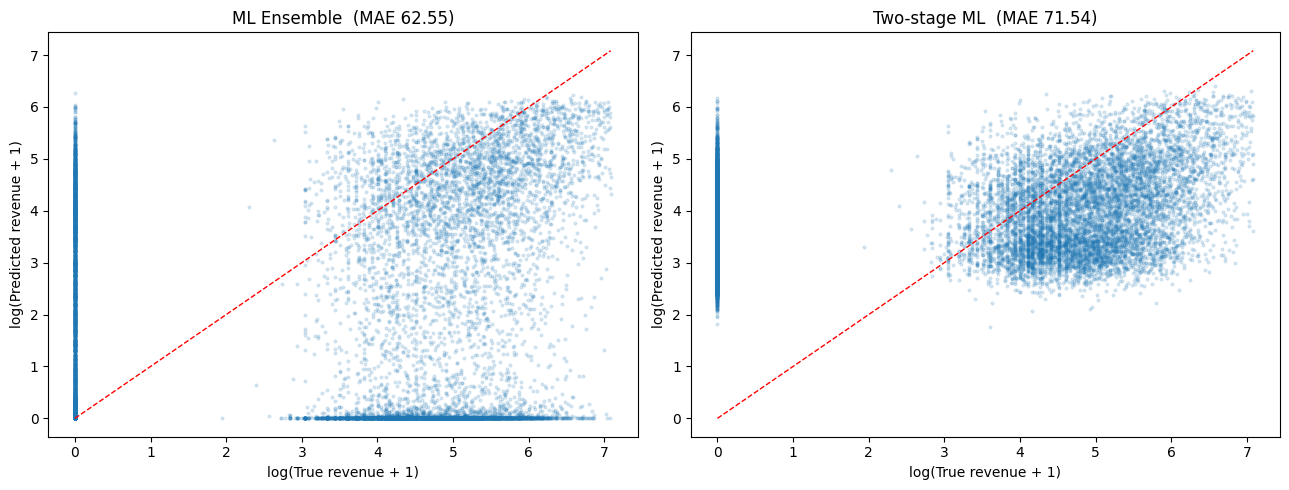

In [113]:
val_pred_lgb   = np.expm1(final_lgb.predict(X_val)).clip(0)
val_pred_xgb   = np.expm1(final_xgb.predict(X_val)).clip(0)
val_pred_cat   = np.expm1(final_cat.predict(X_val)).clip(0)
val_pred_ml    = w_lgb * val_pred_lgb + w_xgb * val_pred_xgb + w_cat * val_pred_cat

bgnbd_val      = df_val["bgnbd_clv"].fillna(0).clip(0).values
val_pred_blend = alpha_opt * bgnbd_val + (1 - alpha_opt) * val_pred_ml

# Soft scaling: conditional revenue × p_alive
p_alive_val    = df_val["p_alive"].fillna(0).clip(0).values
cond_log_val   = (cond_lgb.predict(X_val) +
                  cond_xgb.predict(X_val) +
                  cond_cat.predict(X_val)) / 3
val_pred_soft  = (p_alive_val * np.expm1(cond_log_val).clip(0))

# Two-stage: classifier × conditional regressor
p_return_val        = final_clf.predict_proba(X_val)[:, 1]
cond_log_val_ts     = final_cond_reg.predict(X_val)
cond_rev_val_ts     = np.expm1(cond_log_val_ts).clip(0)
val_pred_twostage   = p_return_val * cond_rev_val_ts
val_pred_ts_thresh  = np.where(val_pred_twostage < best_threshold, 0.0, val_pred_twostage)

print(f"{'Model':<44} {'Val MAE':>9}  {'Spearman':>10}")
print("-" * 67)
all_val_results = {}
for label, preds in [
    ("BG/NBD standalone",                         bgnbd_val),
    ("LightGBM only",                             val_pred_lgb),
    ("XGBoost only",                              val_pred_xgb),
    ("CatBoost only",                             val_pred_cat),
    ("ML weighted ensemble",                      val_pred_ml),
    (f"ML + BG/NBD blend (α={alpha_opt:.2f})",    val_pred_blend),
    ("P_alive × conditional revenue",             val_pred_soft),
    ("Two-stage ML (clf × regressor)",            val_pred_twostage),
    (f"Two-stage + threshold ({best_threshold:.0f}€)", val_pred_ts_thresh),
]:
    mae  = mean_absolute_error(y_val_raw, preds)
    corr, _ = spearmanr(y_val_raw, preds)
    all_val_results[label] = (mae, corr)
    print(f"{label:<44} {mae:>9.2f}  {corr:>10.4f}")

# Pick the best val prediction for scatter plot
best_val_label = min(all_val_results, key=lambda k: all_val_results[k][0])
val_pred_best  = dict(zip(
    [label for label, _ in [
        ("BG/NBD standalone", bgnbd_val), ("LightGBM only", val_pred_lgb),
        ("XGBoost only", val_pred_xgb), ("CatBoost only", val_pred_cat),
        ("ML weighted ensemble", val_pred_ml),
        (f"ML + BG/NBD blend (α={alpha_opt:.2f})", val_pred_blend),
        ("P_alive × conditional revenue", val_pred_soft),
        ("Two-stage ML (clf × regressor)", val_pred_twostage),
        (f"Two-stage + threshold ({best_threshold:.0f}€)", val_pred_ts_thresh),
    ]],
    [bgnbd_val, val_pred_lgb, val_pred_xgb, val_pred_cat, val_pred_ml,
     val_pred_blend, val_pred_soft, val_pred_twostage, val_pred_ts_thresh],
))[best_val_label]

# Scatter: ML ensemble vs two-stage (or best)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
ml_mae  = all_val_results["ML weighted ensemble"][0]
ts_mae  = all_val_results["Two-stage ML (clf × regressor)"][0]
for ax, preds, title in [
    (axes[0], val_pred_ml,        f"ML Ensemble  (MAE {ml_mae:.2f})"),
    (axes[1], val_pred_twostage,  f"Two-stage ML  (MAE {ts_mae:.2f})"),
]:
    ax.scatter(np.log1p(y_val_raw), np.log1p(preds), alpha=0.15, s=4)
    lim = max(np.log1p(y_val_raw).max(), np.log1p(preds).max())
    ax.plot([0, lim], [0, lim], "r--", lw=1)
    ax.set_xlabel("log(True revenue + 1)")
    ax.set_ylabel("log(Predicted revenue + 1)")
    ax.set_title(title)
plt.tight_layout()
plt.show()

In [114]:
# Save all models and metadata
joblib.dump(final_lgb,    "../models/ml_lgb_model.pkl")
joblib.dump(final_xgb,    "../models/ml_xgb_model.pkl")
joblib.dump(final_cat,    "../models/ml_cat_model.pkl")
joblib.dump(cond_lgb,     "../models/cond_lgb_model.pkl")
joblib.dump(cond_xgb,     "../models/cond_xgb_model.pkl")
joblib.dump(cond_cat,     "../models/cond_cat_model.pkl")
joblib.dump(final_clf,    "../models/churn_clf_model.pkl")
joblib.dump(final_cond_reg, "../models/cond_reg_model.pkl")

joblib.dump({"w_lgb": w_lgb, "w_xgb": w_xgb, "w_cat": w_cat},
                              "../models/ml_ensemble_weights.pkl")
joblib.dump(alpha_opt,        "../models/blend_alpha.pkl")
joblib.dump(feature_cols_ml,  "../models/feature_cols_ml.pkl")
joblib.dump(USE_BLEND,        "../models/use_blend.pkl")
joblib.dump(USE_SOFT_SCALING, "../models/use_soft_scaling.pkl")
joblib.dump(USE_TWOSTAGE,     "../models/use_twostage.pkl")
joblib.dump(USE_THRESHOLD,    "../models/use_threshold.pkl")
joblib.dump(best_threshold,   "../models/pred_threshold.pkl")

print("Models saved:")
print("  ml_lgb/xgb/cat_model.pkl  (single-stage MAE ensemble)")
print("  cond_lgb/xgb/cat_model.pkl  (conditional revenue for soft scaling)")
print("  churn_clf_model.pkl + cond_reg_model.pkl  (two-stage ML)")
print(f"  ml_ensemble_weights: LGB={w_lgb:.3f} XGB={w_xgb:.3f} CAT={w_cat:.3f}")
print(f"  blend_alpha={alpha_opt:.4f}  |  feature_cols_ml ({len(feature_cols_ml)} features)")
print(f"  Strategy flags: USE_TWOSTAGE={USE_TWOSTAGE}  USE_THRESHOLD={USE_THRESHOLD}")
print(f"                  threshold={best_threshold:.1f}€  USE_BLEND={USE_BLEND}")

Models saved:
  ml_lgb/xgb/cat_model.pkl  (single-stage MAE ensemble)
  cond_lgb/xgb/cat_model.pkl  (conditional revenue for soft scaling)
  churn_clf_model.pkl + cond_reg_model.pkl  (two-stage ML)
  ml_ensemble_weights: LGB=0.238 XGB=0.214 CAT=0.548
  blend_alpha=0.0000  |  feature_cols_ml (81 features)
  Strategy flags: USE_TWOSTAGE=False  USE_THRESHOLD=False
                  threshold=83.9€  USE_BLEND=True
